In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.



In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import scanpy as sc
import pyro.distributions as dist
from rs3.seq import predict_seq
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = True


In [4]:
adata = ad.read_h5ad("PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [6]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [7]:
adata.obs["guide_id"].str.replace("g[0-9]+$", "", regex=True)
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [8]:
adata.layers["norm"] = sc.pp.normalize_total(adata, inplace=False)["X"]


In [9]:
layer = None
layer = "norm"
bc_name="bc"


target_genes = [g for g in adata.obs["element"].unique() if g != "control"]
cell_elements = adata.obs[["element", "guide_id"]].reset_index(names=bc_name)

target_df = (
    adata[:, target_genes]
    .to_df(layer=layer)
    .melt(ignore_index=False)
    .reset_index(names=bc_name)
    .rename(columns={"gene_symbol": "element"})
    .assign(group="targeted")
)

target_expr = cell_elements.merge(target_df, how="inner").assign(
    guide_number=lambda x: x["guide_id"].str.replace(".+g", "", regex=True)
)


control_bcs = cell_elements.query("element=='control'").drop(columns="element")
control_expr = (
    adata[:, target_genes]
    .to_df(layer=layer)
    .melt(ignore_index=False)
    .reset_index(names=bc_name)
    .merge(control_bcs, on=[bc_name])
    .assign(guide_number=lambda x: "NT")
    .rename(columns={"gene_symbol": "element"})
    .assign(group="control")
)
# control_expr
# target_expr

control_and_target_expr = pd.concat((target_expr, control_expr), axis=0)
control_and_target_expr


,bc,element,guide_id,value,group,guide_number
0,AAACCTGAGCCAGAAC,STAT2,STAT2g2,0.000000,targeted,2
1,AAACCTGAGTGGACGT,CAV1,CAV1g4,0.000000,targeted,4
2,AAACCTGCATGAGCGA,STAT1,STAT1g2,0.774449,targeted,2
3,AAACCTGTCTTGTCAT,CD86,CD86g1,0.000000,targeted,1
4,AAACGGGAGAACAACT,IRF7,IRF7g2,3.664323,targeted,2
...,...,...,...,...,...,...
59645,TTTCCTCTCAGCAACT,MYC,NTg2,0.000000,control,NT
59646,TTTGGTTGTTCCTCCA,MYC,NTg5,0.000000,control,NT
59647,TTTGGTTTCGACCAGC,MYC,NTg9,0.000000,control,NT
59648,TTTGTCAAGTTACGGG,MYC,NTg10,0.526492,control,NT


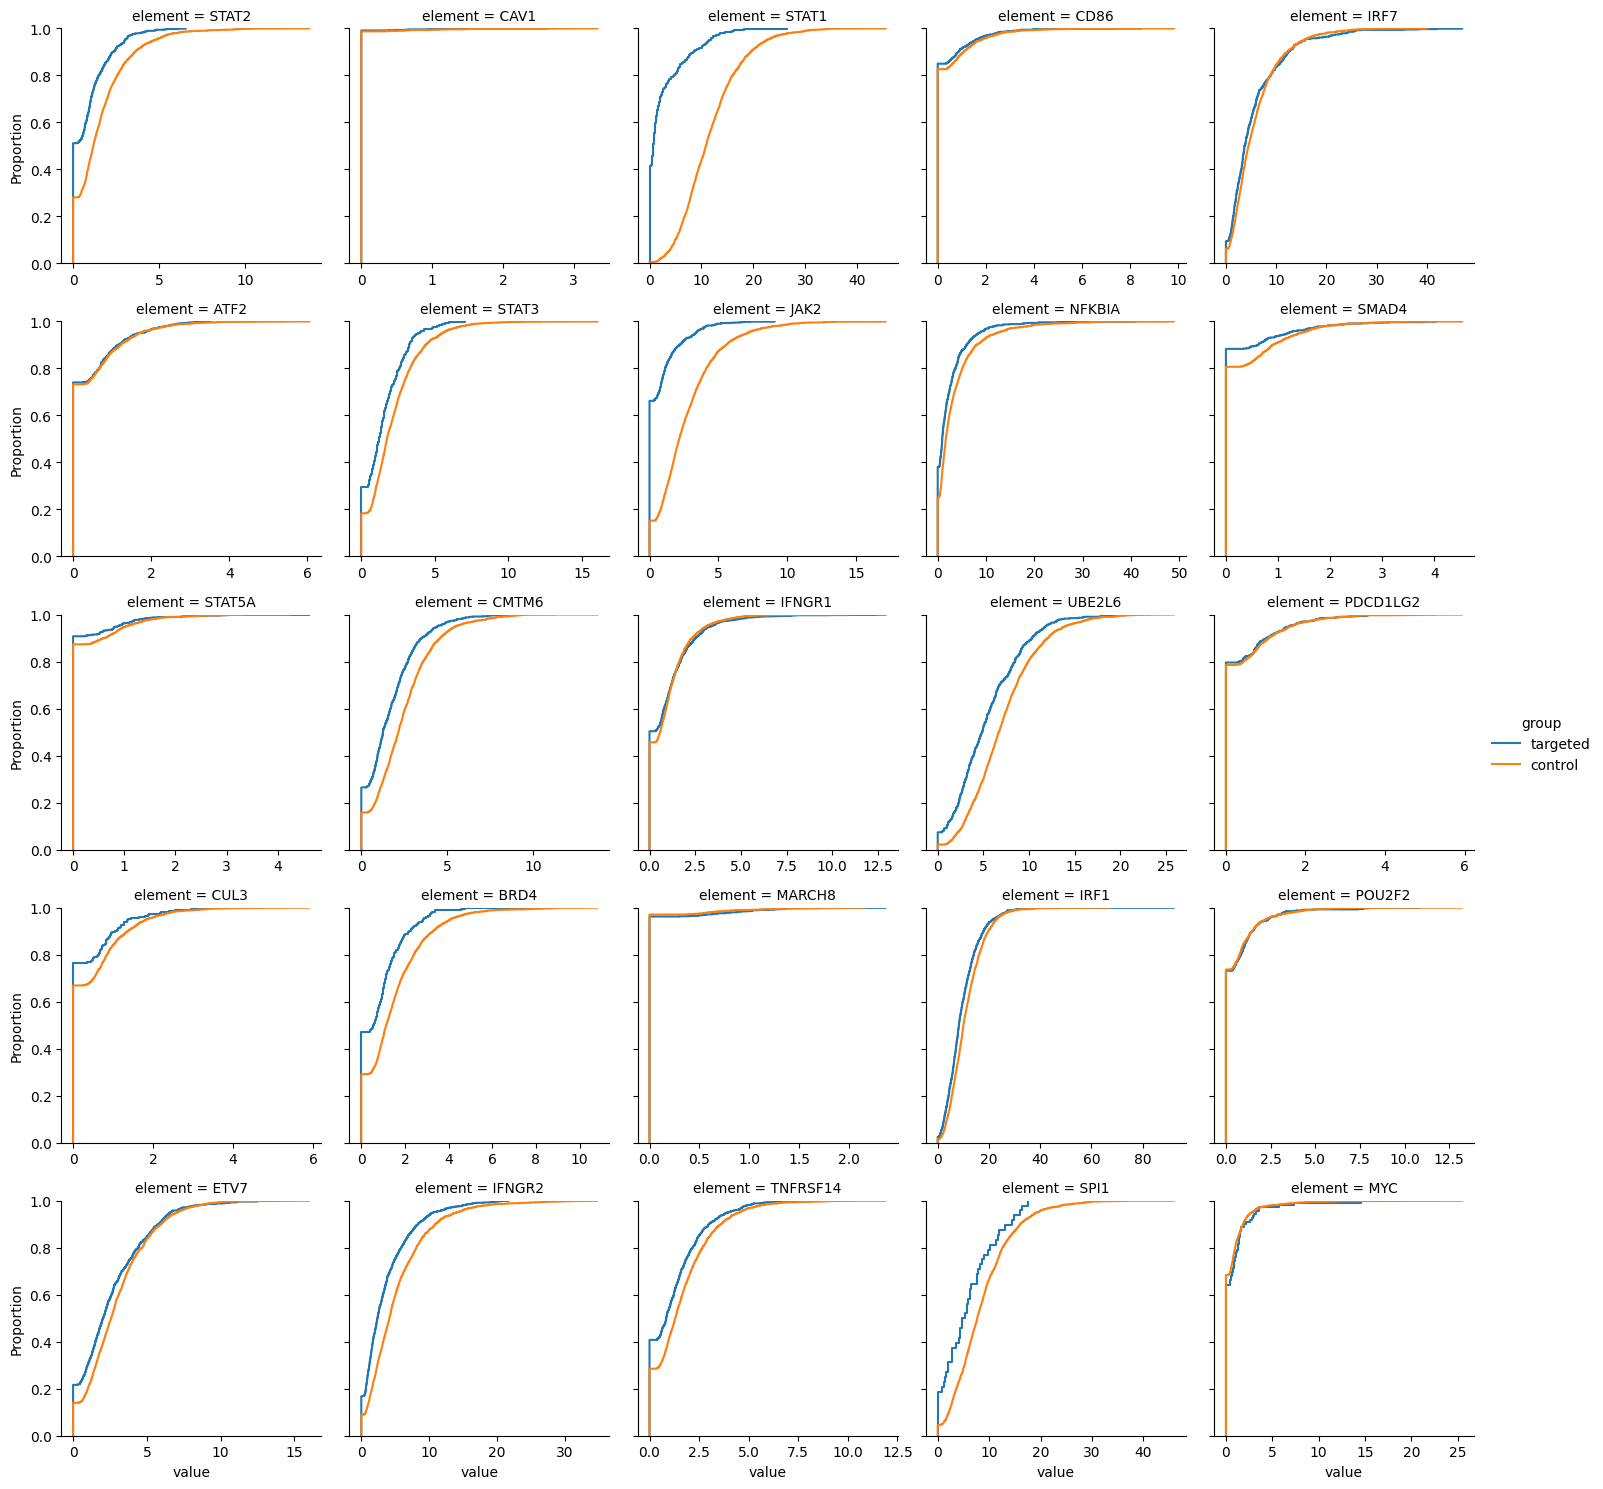

In [10]:
plot_type = sns.ecdfplot
# plot_type = sns.kdeplot

# Add other colors for the remaining guide_ids if needed
# For example, you can use the default Seaborn color palette for other guide_ids
# plot the ecdfs broken down by control vs. targeted
g = sns.FacetGrid(control_and_target_expr, col="element", hue="group", col_wrap=5, sharex=False, sharey=True)
g.map(plot_type, "value")
g.add_legend()
plt.show()


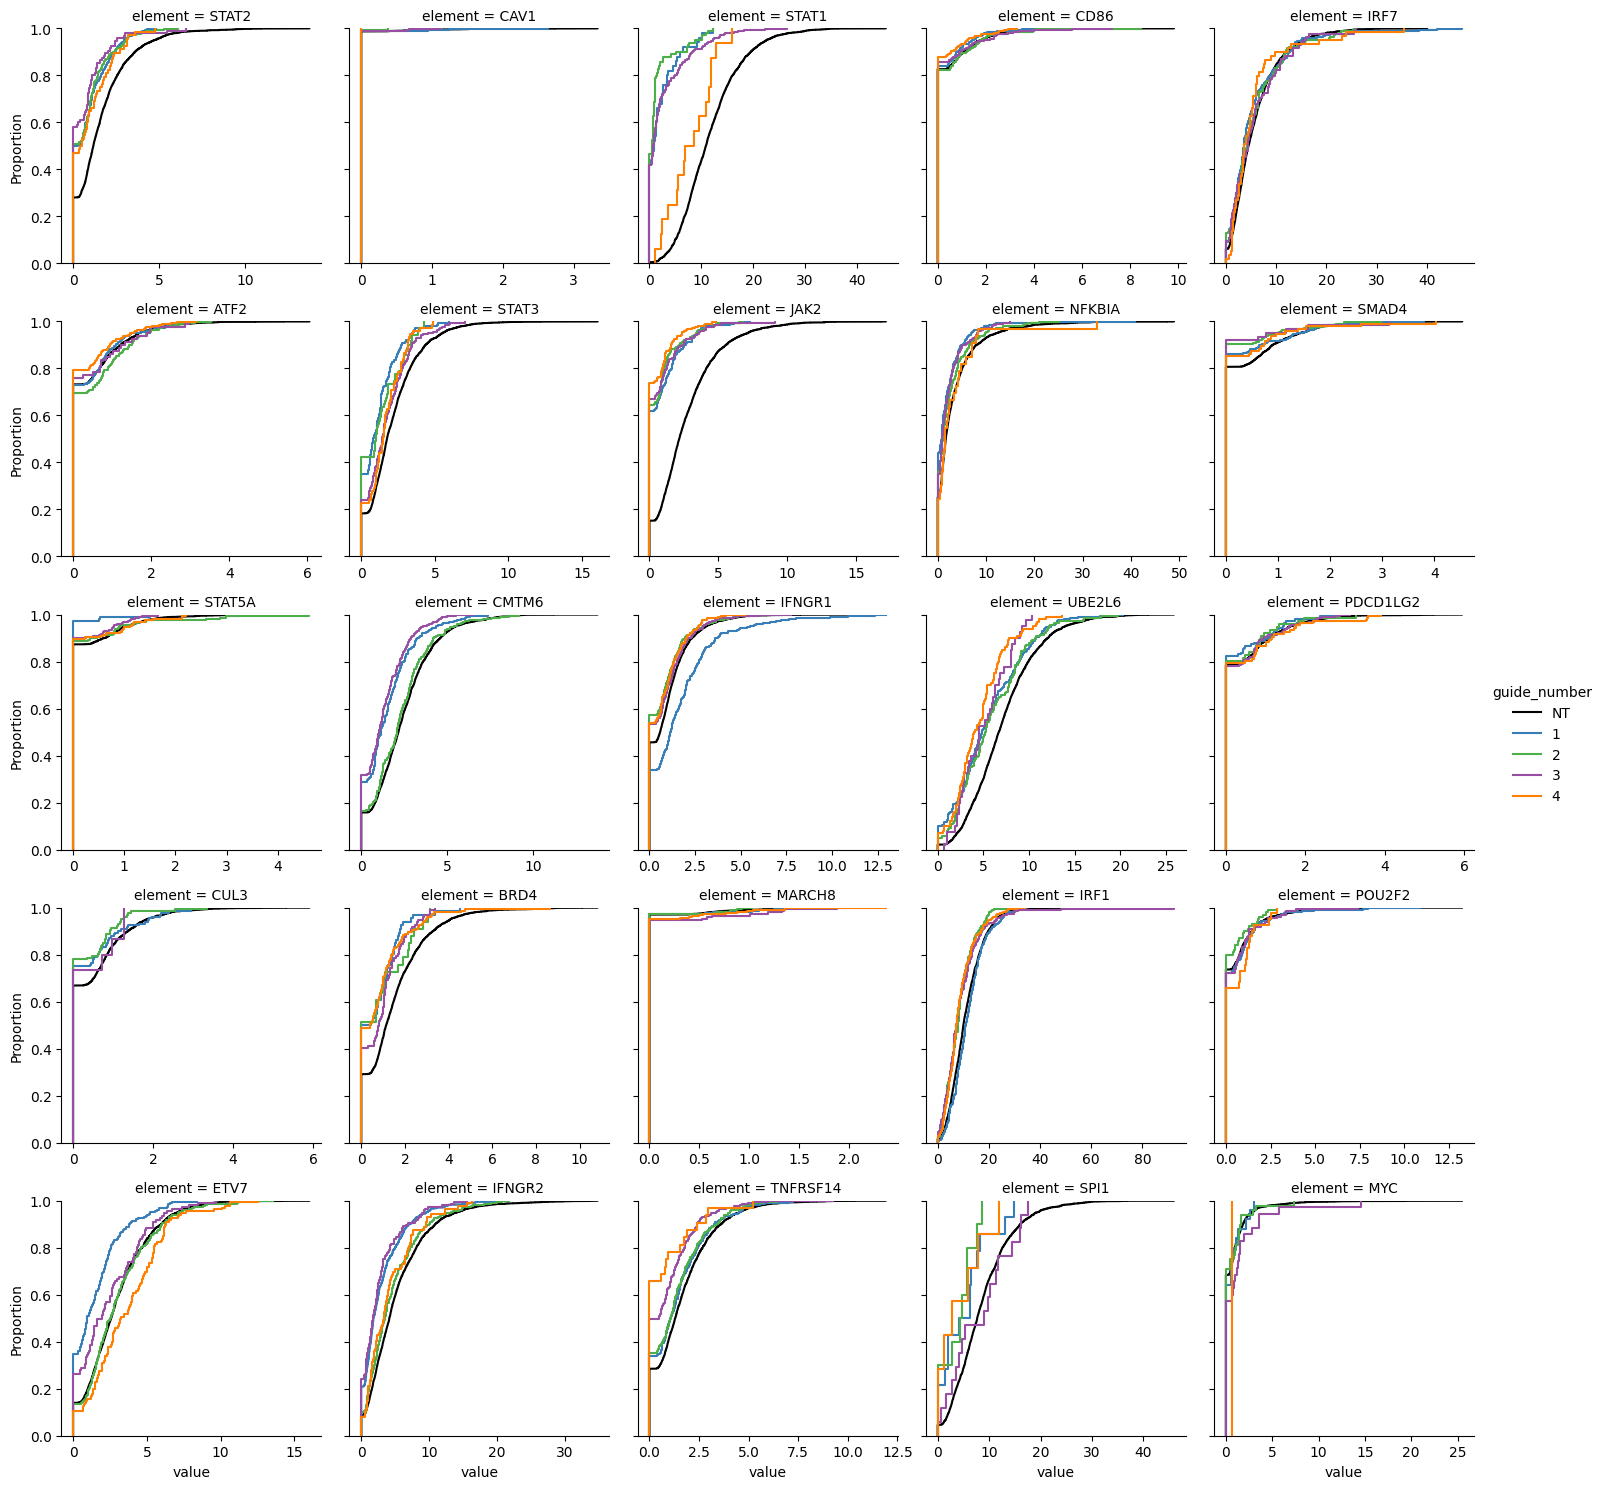

In [11]:
plot_type = sns.ecdfplot
# plot_type = sns.histplot

palette = sns.color_palette("Set1")
palette[0]="black"

# plot the ecdfs broken down by guide_id
g = sns.FacetGrid(
    control_and_target_expr,
    col="element",
    hue="guide_number",
    col_wrap=5,
    sharex=False,
    sharey=True,
    palette=palette,
    hue_order=["NT"]+[str(i) for i in range(1, 5)],
)

if plot_type==sns.histplot:
    g.map(plot_type, "value",common_norm=False,stat="density", bins=np.arange(0,20,step=1))
if plot_type == sns.kdeplot:
    raise ValueError("Counts too low for kdeplot")
else:
    g.map(plot_type, "value")

g.add_legend()

plt.show()


In [12]:
prot_adata = ad.read_h5ad("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

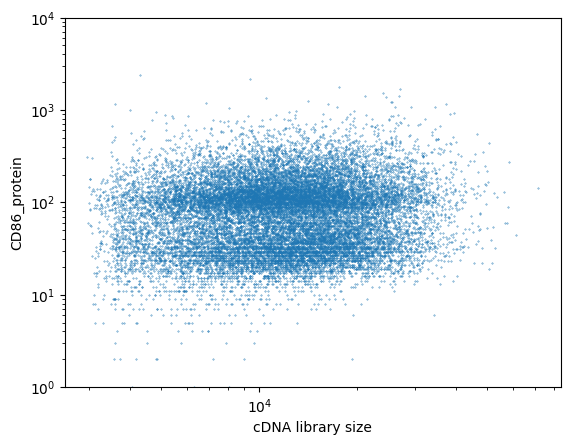

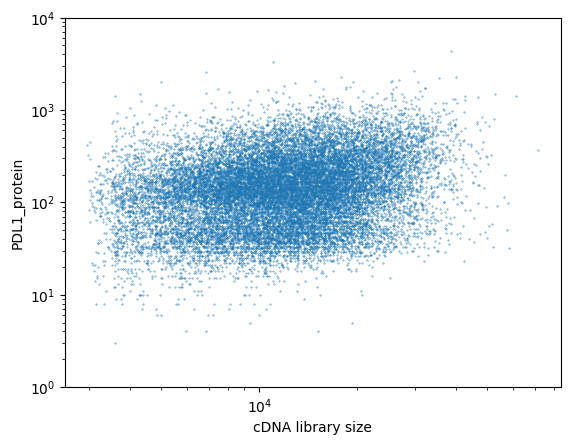

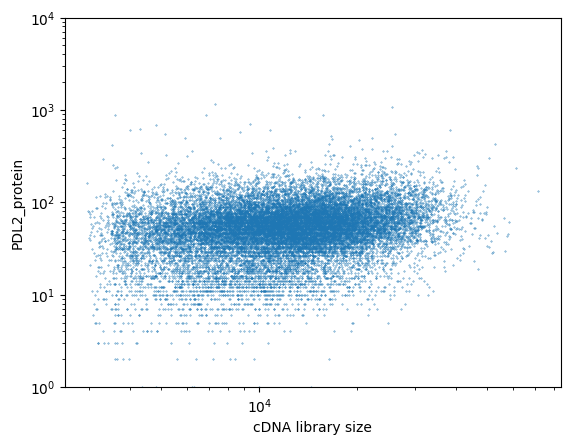

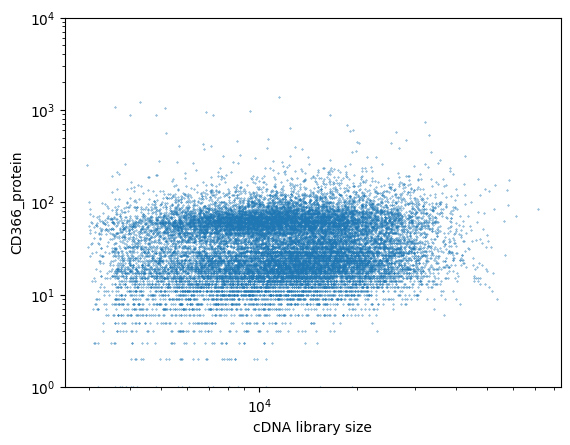

In [13]:
# plt.scatter(prot_adata.X.sum(axis=1).A1, adata.X.sum(axis=1).A1, s=0.1)

for prot_var in prot_adata.var_names:
    plt.scatter(adata.X.sum(axis=1).A1, prot_adata[:, prot_var].X.todense().A1, s=0.1)
    plt.ylabel(prot_var)
    plt.xlabel("cDNA library size")
    plt.ylim([1, 1e4])
    plt.loglog()
    plt.show()

    # sns.violinplot(prot_adata[:, prot_var].X.todense().A1)


# plt.axline((0,0), slope=1)


In [14]:
prot_df = (
    prot_adata.to_df()
    .join(prot_adata.obs)
    .assign(element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True))
    .assign(targeted=lambda x: x["element"]!="control")
    .assign(guide_number=lambda x: x["perturbation"].str.replace("^.*g","",regex=True))
)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element,targeted,guide_number
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,monocytes,human,1,4,801.0,0.0,0.0,STAT2,True,2
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,monocytes,human,1,4,545.0,0.0,0.0,CAV1,True,4
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,monocytes,human,1,4,344.0,0.0,0.0,STAT1,True,2
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,monocytes,human,1,4,539.0,0.0,0.0,CD86,True,1
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,monocytes,human,1,4,1053.0,0.0,0.0,IRF7,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,monocytes,human,1,4,398.0,0.0,0.0,CMTM6,True,1
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,monocytes,human,0,4,3042.0,0.0,0.0,control,False,control
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,monocytes,human,1,4,212.0,0.0,0.0,ATF2,True,1
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,monocytes,human,1,4,258.0,0.0,0.0,CAV1,True,2


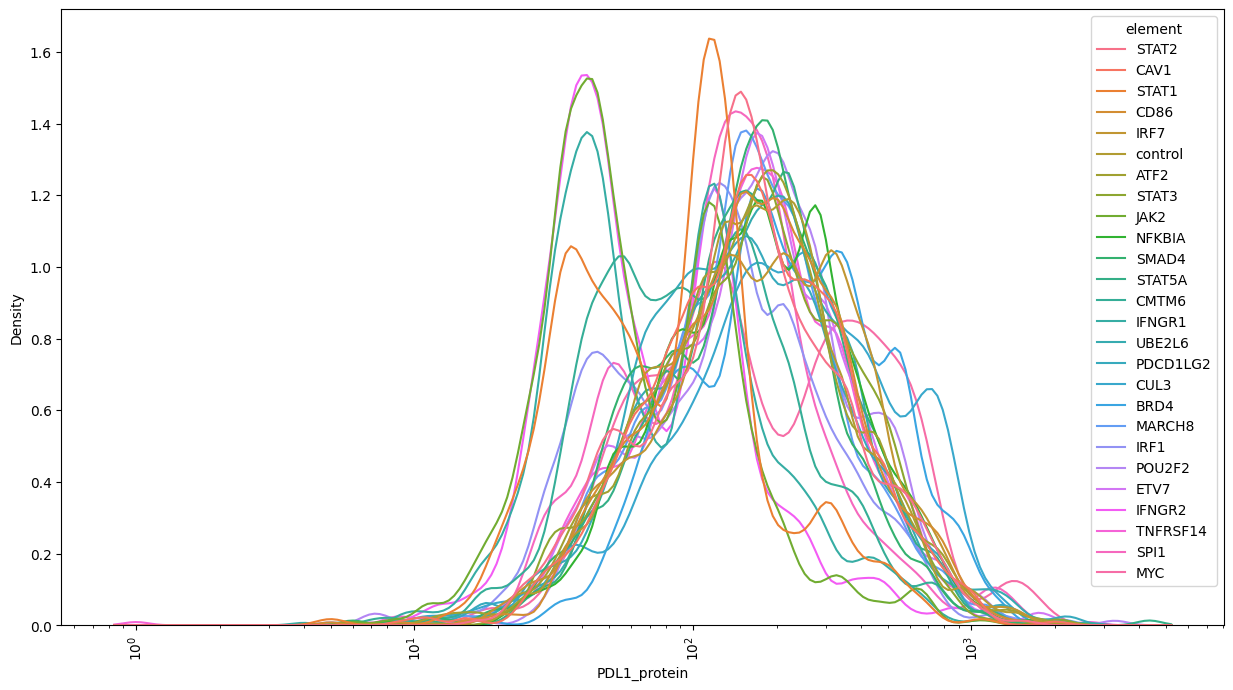

In [15]:
# for
plt.figure(figsize=(15, 8))
sns.kdeplot(
    prot_df.assign(PDL1_protein=lambda x: x["PDL1_protein"]+1),
    hue="element",
    x="PDL1_protein",
    log_scale=True,
    common_grid=True,
    common_norm=False,
    bw_adjust=0.5,
)
plt.xticks(rotation=90)
plt.show()


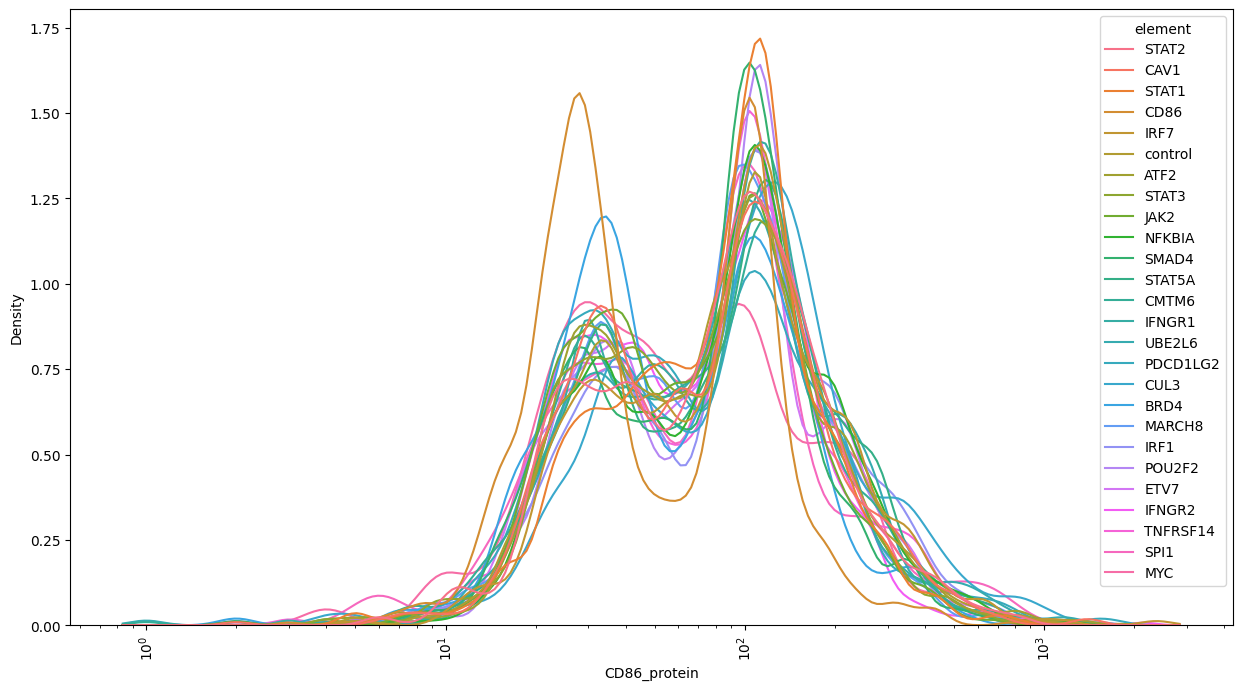

In [16]:
# for
plt.figure(figsize=(15, 8))
sns.kdeplot(prot_df, hue="element", x="CD86_protein", log_scale=True, common_grid=True, common_norm=False, bw_adjust=0.5)
plt.xticks(rotation=90)
plt.show()


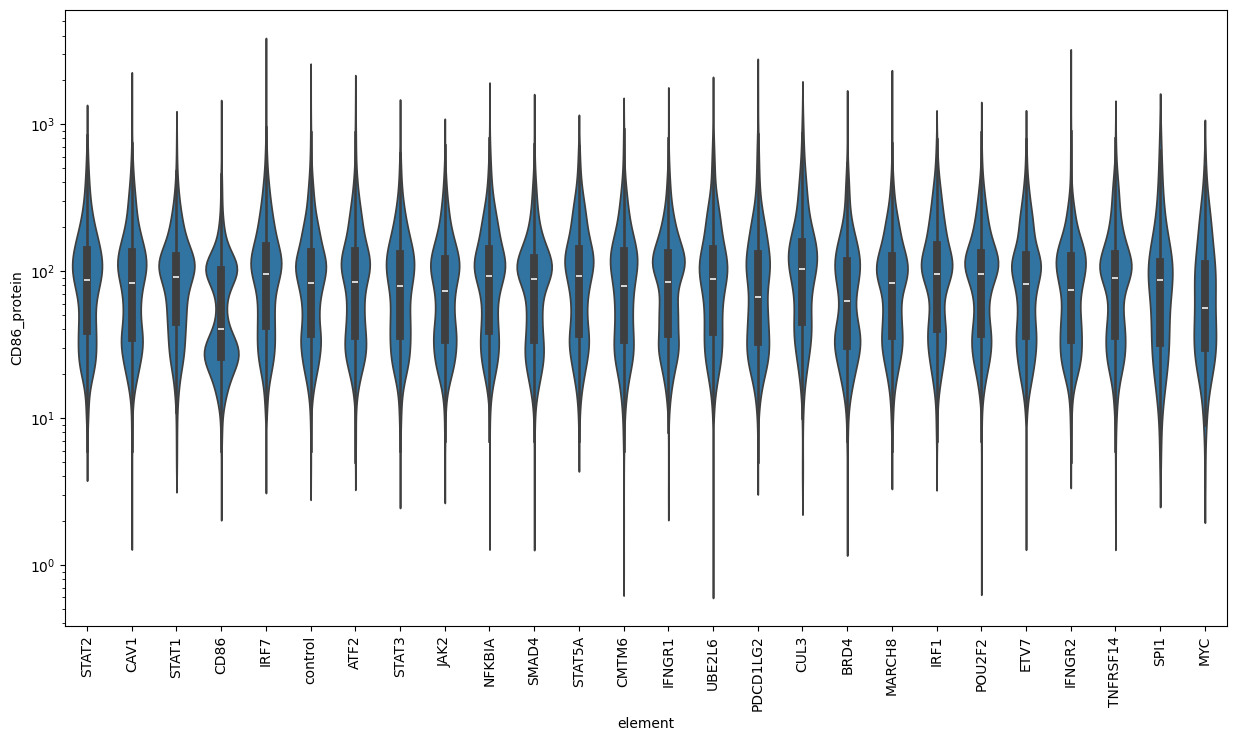

In [17]:
# for
plt.figure(figsize=(15, 8))
sns.violinplot(prot_df, x="element", y="CD86_protein", log_scale=True)
plt.xticks(rotation=90)
plt.show()

In [18]:
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

def plot_interactive(plot_type, hue_column, protein_column):
    elements = sorted([x for x in prot_df["element"].unique() if x != "control"])
    print(len(elements))
    fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(25, 25))
    for ax, element in zip(axs.ravel(), elements):
        plot_data = prot_df.query(f"element=='{element}' or element=='control'")
        ax.set_title(element)
        if plot_type == "ecdf":
            sns.ecdfplot(
                plot_data,
                x=protein_column,
                hue=hue_column,
                ax=ax,
                hue_order=["control"] + [str(i) for i in range(1, 5)] if hue_column == "guide_number" else None,
            )
        else:
            sns.kdeplot(
                plot_data.assign(value=lambda x: x[protein_column] + 1),
                x="value",
                hue=hue_column,
                common_grid=True,
                common_norm=False,
                log_scale=True,
                bw_adjust=0.5,
                ax=ax,
                hue_order=["control"] + [str(i) for i in range(1, 5)] if hue_column == "guide_number" else None,
            )
    fig.suptitle(protein_column)
    plt.show()

plot_type_widget = widgets.Dropdown(
    options=["kde", "ecdf"],
    value="kde",
    description="Plot Type:",
)

hue_column_widget = widgets.Dropdown(
    options=["targeted", "guide_number"],
    value="targeted",
    description="Hue Column:",
)

protein_column_widget = widgets.Dropdown(
    options=["CD86_protein", "PDL1_protein"],
    value="PDL1_protein",
    description="Protein Column:",
)

interact(plot_interactive, plot_type=plot_type_widget, hue_column=hue_column_widget, protein_column=protein_column_widget)


interactive(children=(Dropdown(description='Plot Type:', options=('kde', 'ecdf'), value='kde'), Dropdown(descr…

<function __main__.plot_interactive(plot_type, hue_column, protein_column)>

In [19]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [20]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones
if smoke_test:
    n_genes_subset = 50
else:
    n_genes_subset = 1000
target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
# target_genes += prot_adata.var_names.tolist()
hvg_rank = sc.pp.highly_variable_genes(adata, inplace=False, flavor="seurat_v3")
hvgs = hvg_rank.nlargest(n_genes_subset, "variances_norm").index
other_genes = [gene for gene in hvgs if gene not in target_genes]
selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
# selected_genes = stat_target_genes + list(
#     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
# )

# selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# guide_filter = adata.obs["perturbation"].isin(selected_guides)
# adata_subset = adata[guide_filter, :][:, selected_genes]
adata_subset = adata[:, selected_genes]

# else:
#     min_counts = 100 # min no. of cells with at least 1 count
#     selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
#     adata_subset = adata[:, selected_genes]
# adata_subset

In [21]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'CCL8', 'CCL4', 'CCL7', 'FABP4', 'IGFBP5',
       'C1QC', 'CDC20', 'CCL2', 'CCL3', 'SPP1', 'KRT17', 'C1QB', 'CXCL3',
       'AKR1C2', 'GNLY', 'C15orf48', 'SERPINE2', 'CXCL9', 'TDO2', 'CCL13',
       'CXCL11', 'CCL20', 'S100A12', 'IL1B', 'MMP9'],
      dtype='object', name='gene_symbol')

In [22]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [23]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)

guide_by_element = guide_by_element.iloc[:,:-1] # remove control
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [24]:
n_elements = guide_by_element.shape[1]
gene_by_element = (
    pd.DataFrame(np.eye(n_elements), index=guide_by_element.columns, columns=guide_by_element.columns)
    .reindex(index=adata_subset.var_names)
    .fillna(0)
)
adata_subset.varm["element_targets"] = gene_by_element
adata_subset.varm["element_targets"]

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_41622/1485371578.py:7: ImplicitModificationWarning: Setting element `.varm['element_targets']` of view, initializing view as actual.
  adata_subset.varm["element_targets"] = gene_by_element


element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
gene_symbol,,,,,,,,,,,,,,,,,,,,,
STAT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CAV1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CD86,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRF7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATF2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
JAK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NFKBIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# guide_metadata["gRNA sequence"].str.strip()


In [26]:
# from rs3.seq import predict_seq
# [len(s) for s in context_seqs]

<Axes: >

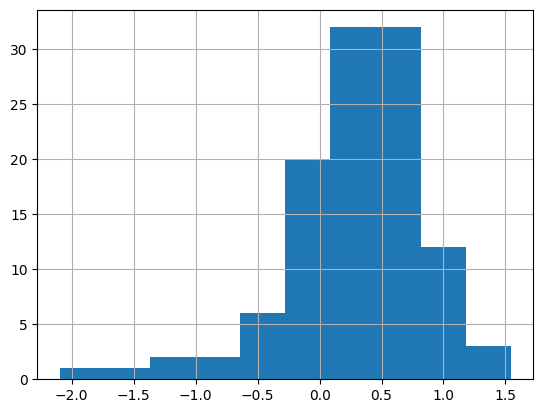

In [27]:
# from doenchScore import calcDoenchScore

guide_metadata = pd.read_csv("papalexi_guide_metadata.csv", index_col=0)

# guide_metadata["score"] = predict_seq(context_seqs, sequence_tracr="Chen2013")

# guide_metadata["rs1_score"] = [
#     calcDoenchScore("AAAC" + g + "CGGTGT") if g != "Non-Targeting" else -1 for g in guide_metadata["gRNA sequence"]
# ]
guide_metadata["rs3_score"].hist()

In [28]:
gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
gdata.var = guide_metadata.loc[gdata.var_names]
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
      varm:	'element_targets'
      layers:	'norm'
    grna:	20729 x 107
      var:	'Gene', 'gRNA sequence', 'rs3_score'
      varm:	'guide_targets'

In [29]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [30]:
mdata["rna"].varm["element_targets"]
mdata["rna"].varm["guide_targets"] = mdata["rna"].varm["element_targets"] @ mdata["grna"].varm["guide_targets"].T
mdata["grna"].varm["guide_identity"] = pd.DataFrame(
    np.eye(mdata["grna"].n_vars),
    index=mdata["grna"].var_names,
    columns=mdata["grna"].var_names,
)

# Remove NT guides
mdata["grna"].varm["guide_identity"] = (
    mdata["grna"].varm["guide_identity"].loc[:, ~mdata["grna"].varm["guide_identity"].columns.str.startswith("NT")]
)

targeting_guides = mdata["grna"].var_names[~mdata["grna"].var_names.str.startswith("NT")]

mdata["rna"].varm["guide_targets"] = mdata["rna"].varm["guide_targets"][targeting_guides]
mdata["grna"].varm["guide_identity"] = mdata["grna"].varm["guide_identity"][targeting_guides]
# mdata["rna"].varm["guide_targets"]
assert (mdata["grna"].varm["guide_identity"].columns == mdata["rna"].varm["guide_targets"].columns).all()

# break

In [31]:
import perturbo

# perturbo.PERTURBO.setup_mudata(
#     mdata,
#     batch_key="hto",
#     library_size_key="ncounts",
#     continuous_covariates_keys=["percent_mito", "percent_ribo"],
#     guide_by_element_key="guide_targets",
#     gene_by_element_key="element_targets",
#     modalities={
#         "rna_layer": "rna",
#         "perturbation_layer": "grna",
#     },
# )

perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_identity",
    gene_by_element_key="guide_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

n_factors = 10 if not smoke_test else 2
n_pert_factors = 20 if not smoke_test else 10

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="nb",
#     efficiency_mode="mixture",
#     n_factors=2,
#     use_interactions=False,
#     n_pert_factors=20,
# )

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="lnnb",
#     efficiency_mode="mixture",
#     n_factors=10 if not smoke_test else 2,
#     # use_interactions=True,
#     # use_crispr_factor=True,
#     # prior_param_dict={"logit_efficacy_alpha": torch.tensor(1.0)},
#     n_pert_factors=20 if not smoke_test else 10,
# )

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="nb",
#     efficiency_mode="scaled",
#     merge_guides_mode="shared",
#     n_factors=n_factors,
#     n_pert_factors=n_pert_factors,
# )

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="lnnb",
#     efficiency_mode="scaled",
#     merge_guides_mode="shared",
#     n_factors=None,
#     n_pert_factors=None,
# )

# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
model = perturbo.PERTURBO(
    mdata,
    likelihood="nb",
    efficiency_mode="mixture",
    use_interactions=True,
    use_crispr_factor=True,
    n_factors=n_factors,
    n_pert_factors=n_pert_factors,
    # merge_guides_mode="partial",
)

model.view_anndata_setup()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['guide_targets']                                            
INFO     Using column names from columns of adata.varm['guide_identity']                                           


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'hto',
│   'gene_by_element_key': 'guide_targets',
│   'rna_element_uns_key': None,
│   'guide_element_uns_key': None,
│   'guide_by_element_key': 'guide_identity',
│   'library_size_key': 'ncounts',
│   'size_factor_key': None,
│   'gene_mean_key': None,
│   'continuous_covariates_keys': ['percent_mito', 'percent_ribo'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  98   │
│    n_tested_elements    │  98   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │          adata.mod['rna'].var['_gene_mean']          │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_identity']       │
│    tested_elements    │        adata.mod['rna'].varm['guide_targets']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

(array([ 12.,  19.,  29.,  28.,  30.,  57., 101.,  97.,  89., 108., 132.,
        105., 122., 115., 120., 153., 161., 167., 162., 221., 238., 206.,
        232., 225., 239., 285., 303., 281., 319., 342., 333., 375., 341.,
        394., 412., 384., 441., 439., 431., 457., 475., 483., 515., 459.,
        454., 519., 493., 473., 486., 473., 470., 454., 463., 430., 429.,
        389., 380., 361., 352., 314., 305., 297., 263., 224., 212., 215.,
        214., 193., 165., 157., 109., 127., 115.,  96.,  83.,  65.,  55.,
         53.,  29.,  31.,  30.,  32.,  13.,  15.,   6.,   9.,   9.,   8.,
          7.,   4.,   4.,   0.,   3.,   2.,   0.,   1.,   0.,   0.,   0.,
          1.]),
 array([-1.36212379, -1.33028825, -1.29845271, -1.26661717, -1.23478163,
        -1.20294609, -1.17111055, -1.13927501, -1.10743947, -1.07560393,
        -1.04376839, -1.01193285, -0.98009731, -0.94826177, -0.91642623,
        -0.88459069, -0.85275515, -0.82091961, -0.78908407, -0.75724853,
        -0.72541299, -0.69

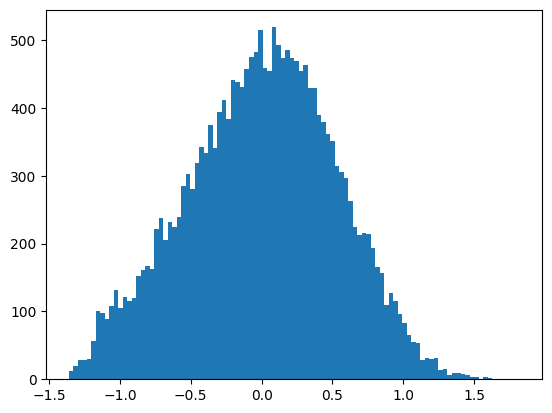

In [32]:
plt.hist(mdata["rna"].obs["_size_factor"], bins=100)


In [33]:
(model.module.guide_by_element.sum(dim=1) > 0).shape

torch.Size([107])

## Set model parameters and train

In [34]:
print(model.module.n_element_effects)

98


In [35]:
model.train(
    1000,
    lr=0.01,
    batch_size=1024,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-2,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 1/1000:   0%|          | 0/1000 [00:00<?, ?it/s]dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
dict_keys(['X', 'size_fact

In [36]:
if "crispr_loading" in model.module.guide.median():
    crispr_loading_mu = model.module.guide.median()["crispr_loading"].squeeze().T.numpy()
    crispr_loading_sigma = (
        crispr_loading_mu - model.module.guide.quantiles([0.17])["crispr_loading"].squeeze().T.numpy()
    )
    crispr_loading_df = pd.DataFrame(
        crispr_loading_mu / crispr_loading_sigma, index=mdata["rna"].var_names, columns=["value"]
    )
    print(crispr_loading_df.sort_values("value").head(20))

                 value
gene_symbol           
CXCL11      -30.042280
C1QC        -21.804924
IRF7        -21.282171
JAK2        -19.752272
CXCL9       -19.485945
C1QB        -18.422710
AKR1C2      -18.371138
IFNGR2      -15.379023
ETV7        -14.899724
IRF1        -14.691031
STAT2       -13.083002
STAT1       -12.126700
UBE2L6      -11.967409
PDCD1LG2    -10.835052
CCL2        -10.029509
TNFRSF14     -9.911161
CCL8         -9.565341
CCL13        -9.224295
NFKBIA       -8.512404
STAT3        -7.188216


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_41622/1760275647.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3679.)
  crispr_loading_mu = model.module.guide.median()["crispr_loading"].squeeze().T.numpy()


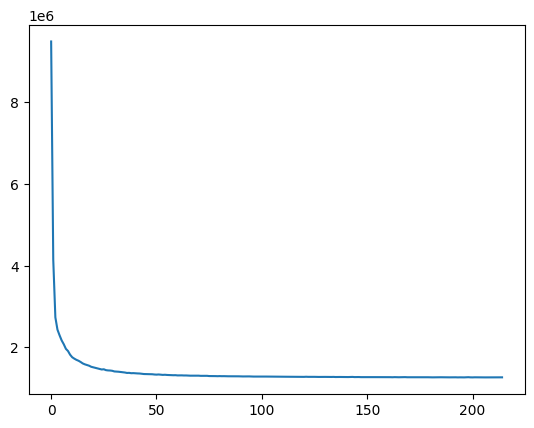

In [37]:
plt.plot(model.history["elbo_train"])

## Inference Results

In [38]:
model.module.guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'pert_cell_factors', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'crispr_loading', 'element_effects'])

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


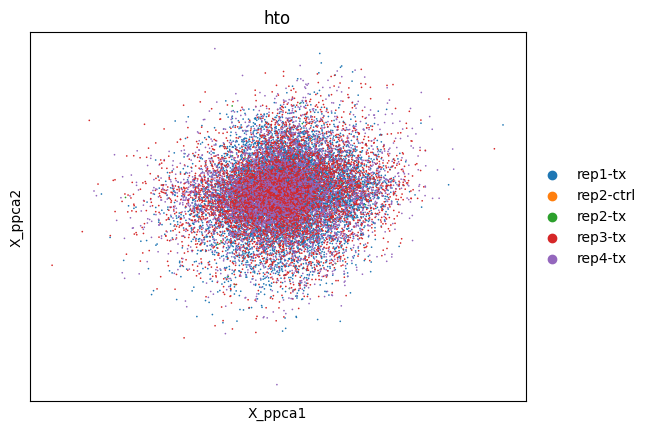

In [39]:
import scanpy as sc
# pyro.get_param_store["cell_factors"].shape
if "cell_factors" in model.module.guide.median():
    cell_factors = model.module.guide.median()["cell_factors"].squeeze().T.numpy()
    # cell_factors = pyro.get_param_store()["AutoGuideList.1.cell_factors"].detach().squeeze().T.numpy()
    mdata["rna"].obsm["X_ppca"] = cell_factors
    sc.pl.embedding(mdata["rna"], basis="X_ppca", color="hto", sort_order=False)

In [40]:
if "cell_loadings" in model.module.guide.median():
    loadings_df = pd.DataFrame(model.module.guide.median()["cell_loadings"].squeeze(), columns=mdata["rna"].var_names)
    print(loadings_df)

gene_symbol     STAT2      CAV1     STAT1      CD86      IRF7      ATF2  \
0           -0.057243 -0.294729 -0.086232  0.154972 -0.153163 -0.207743   
1            0.087846  0.054142  0.090016  0.343541  0.231562 -0.013898   

gene_symbol     STAT3      JAK2    NFKBIA     SMAD4  ...  C15orf48  SERPINE2  \
0           -0.098524 -0.050626 -0.145332 -0.120082  ...  0.570908 -0.066523   
1            0.110435  0.128025  0.395203  0.078272  ...  0.580224 -0.338103   

gene_symbol     CXCL9      TDO2     CCL13    CXCL11     CCL20   S100A12  \
0            0.597292  1.110412  0.922350  0.227255  0.369695  0.223665   
1            0.780004 -0.224748  0.385546  0.954779  0.468749 -0.120640   

gene_symbol      IL1B      MMP9  
0            0.406989  0.298595  
1            0.594728  0.732049  

[2 rows x 50 columns]


In [41]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 98, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 98, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([2, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([2, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([2, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([2, 1, 50])
AutoGuideList.0.locs.pert_cell_factors torch.Size([2, 98, 1])
AutoGuideList.0.scales.pert_cell_factors torch.Size([2, 98, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
Au

In [42]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [43]:
# plt.plot(losses)

In [44]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 98, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 98, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([2, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([2, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([2, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([2, 1, 50])
AutoGuideList.0.locs.pert_cell_factors torch.Size([2, 98, 1])
AutoGuideList.0.scales.pert_cell_factors torch.Size([2, 98, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
Au

In [45]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'pert_cell_factors', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'crispr_loading', 'element_effects'])

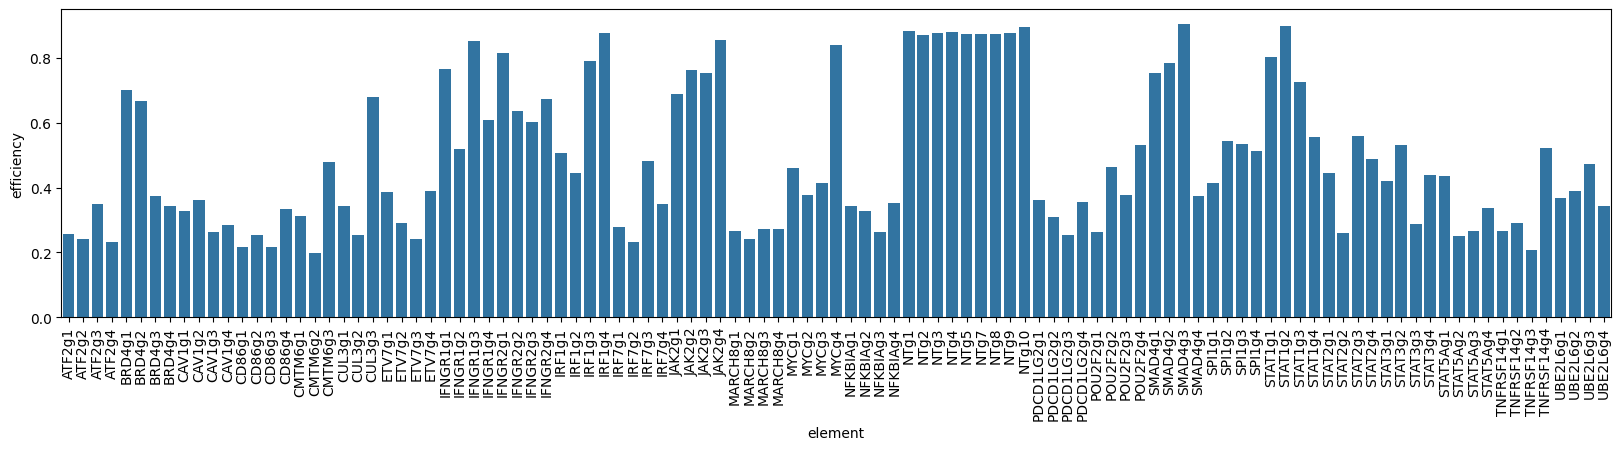

In [46]:
guides = guide_by_element.index
elements = guide_by_element.columns
plt.figure(figsize=(20, 4))
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

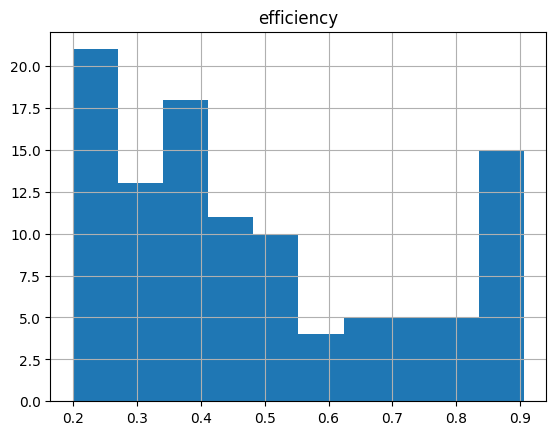

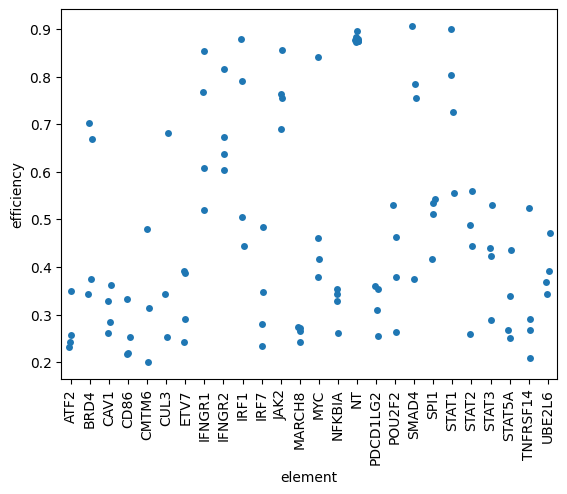

In [47]:
if "guide_efficacy" in guide.median():
    median_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).assign(
        guide=lambda x: x.index,
        element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
    )
    median_efficiency.hist("efficiency")
    plt.show()
    sns.stripplot(median_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

In [48]:
effects_df_long = model.get_element_effects()
effects_df_long

,loc,scale,element,gene,z_value,q_value
76,-2.772273,0.088430,STAT1g3,STAT1,-31.349781,9.796039e-216
75,-2.823813,0.130355,STAT1g2,STAT1,-21.662529,4.630991e-104
43,-1.796069,0.109593,JAK2g2,JAK2,-16.388556,2.308662e-60
42,-1.962983,0.127098,JAK2g1,JAK2,-15.444597,8.203849e-54
74,-2.386558,0.198777,STAT1g1,STAT1,-12.006177,3.297393e-33
...,...,...,...,...,...,...
13,0.685185,0.317138,CD86g2,CD86,2.160526,3.073195e-02
31,0.174011,0.050169,IFNGR2g2,IFNGR2,3.468520,5.233341e-04
25,0.522338,0.106226,ETV7g4,ETV7,4.917211,8.778589e-07
34,0.288924,0.044786,IRF1g1,IRF1,6.451164,1.109944e-10


In [49]:
effect_key="loc"
# effect_key="z_value"
effects_df = effects_df_long.pivot_table(values=effect_key, index="element", columns="gene").fillna(0)
effects_df

gene,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
element,,,,,,,,,,,,,,,,,,,,,
ATF2g1,-0.363896,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
ATF2g2,0.298159,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
ATF2g3,-0.165171,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
ATF2g4,-0.961568,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
BRD4g1,0.000000,-0.657434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.340627,0.000000
UBE2L6g1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-0.773778
UBE2L6g2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-0.344763


In [50]:
cis_effects = (
    effects_df_long.assign(guide_number=lambda x: x["element"].str.replace(".+g", "", regex=True))
    .assign(target=lambda x: x["element"].str.replace("g[0-9]+$", "", regex=True))
    .query("target==gene")
)
# cis_effects = effects_df_long.query("element==gene")
cis_effects

,loc,scale,element,gene,z_value,q_value,guide_number,target
76,-2.772273,0.088430,STAT1g3,STAT1,-31.349781,9.796039e-216,3,STAT1
75,-2.823813,0.130355,STAT1g2,STAT1,-21.662529,4.630991e-104,2,STAT1
43,-1.796069,0.109593,JAK2g2,JAK2,-16.388556,2.308662e-60,2,JAK2
42,-1.962983,0.127098,JAK2g1,JAK2,-15.444597,8.203849e-54,1,JAK2
74,-2.386558,0.198777,STAT1g1,STAT1,-12.006177,3.297393e-33,1,STAT1
...,...,...,...,...,...,...,...,...
13,0.685185,0.317138,CD86g2,CD86,2.160526,3.073195e-02,2,CD86
31,0.174011,0.050169,IFNGR2g2,IFNGR2,3.468520,5.233341e-04,2,IFNGR2
25,0.522338,0.106226,ETV7g4,ETV7,4.917211,8.778589e-07,4,ETV7
34,0.288924,0.044786,IRF1g1,IRF1,6.451164,1.109944e-10,1,IRF1


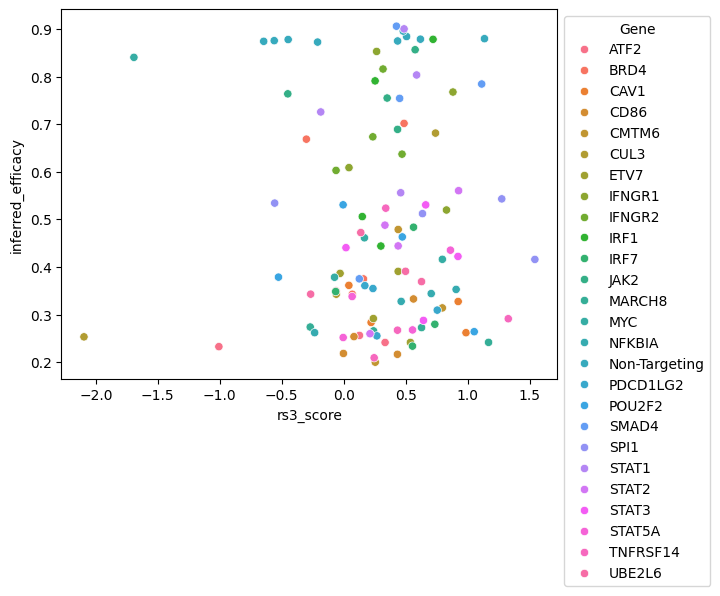

In [51]:
# plot_genes = cis_effects.nsmallest()
from scipy.stats import pearsonr, spearmanr

if "guide_efficacy" in guide.median():
    mdata["grna"].var = mdata["grna"].var.assign(
        inferred_efficacy=guide.median()["guide_efficacy"].detach().cpu(),
    )

    # plot_genes=["STAT1","JAK2","NFKBIA"]
    # plot_data = mdata["grna"].var[mdata["grna"].var["Gene"].isin(plot_genes)]
    plot_data = mdata["grna"].var

    g = sns.scatterplot(plot_data, x="rs3_score", y="inferred_efficacy", hue="Gene")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plot_data.sort_values("inferred_efficacy")
    spearmanr(plot_data["rs3_score"], plot_data["inferred_efficacy"])
    # mdata["grna"].var

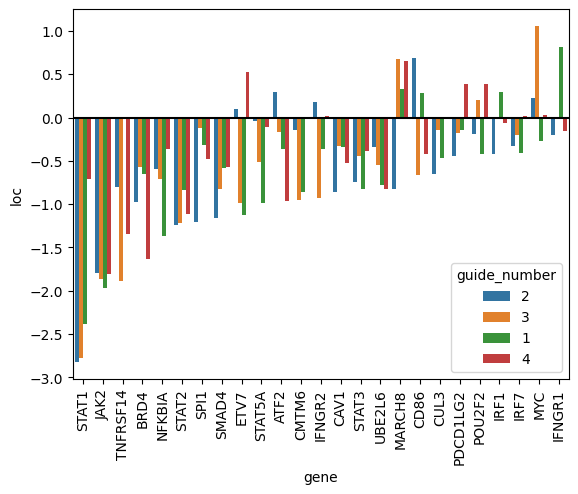

In [52]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect
# key="z_value"
key="loc"
sns.barplot(cis_effects.sort_values(key), x="gene", hue="guide_number", y=key)
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

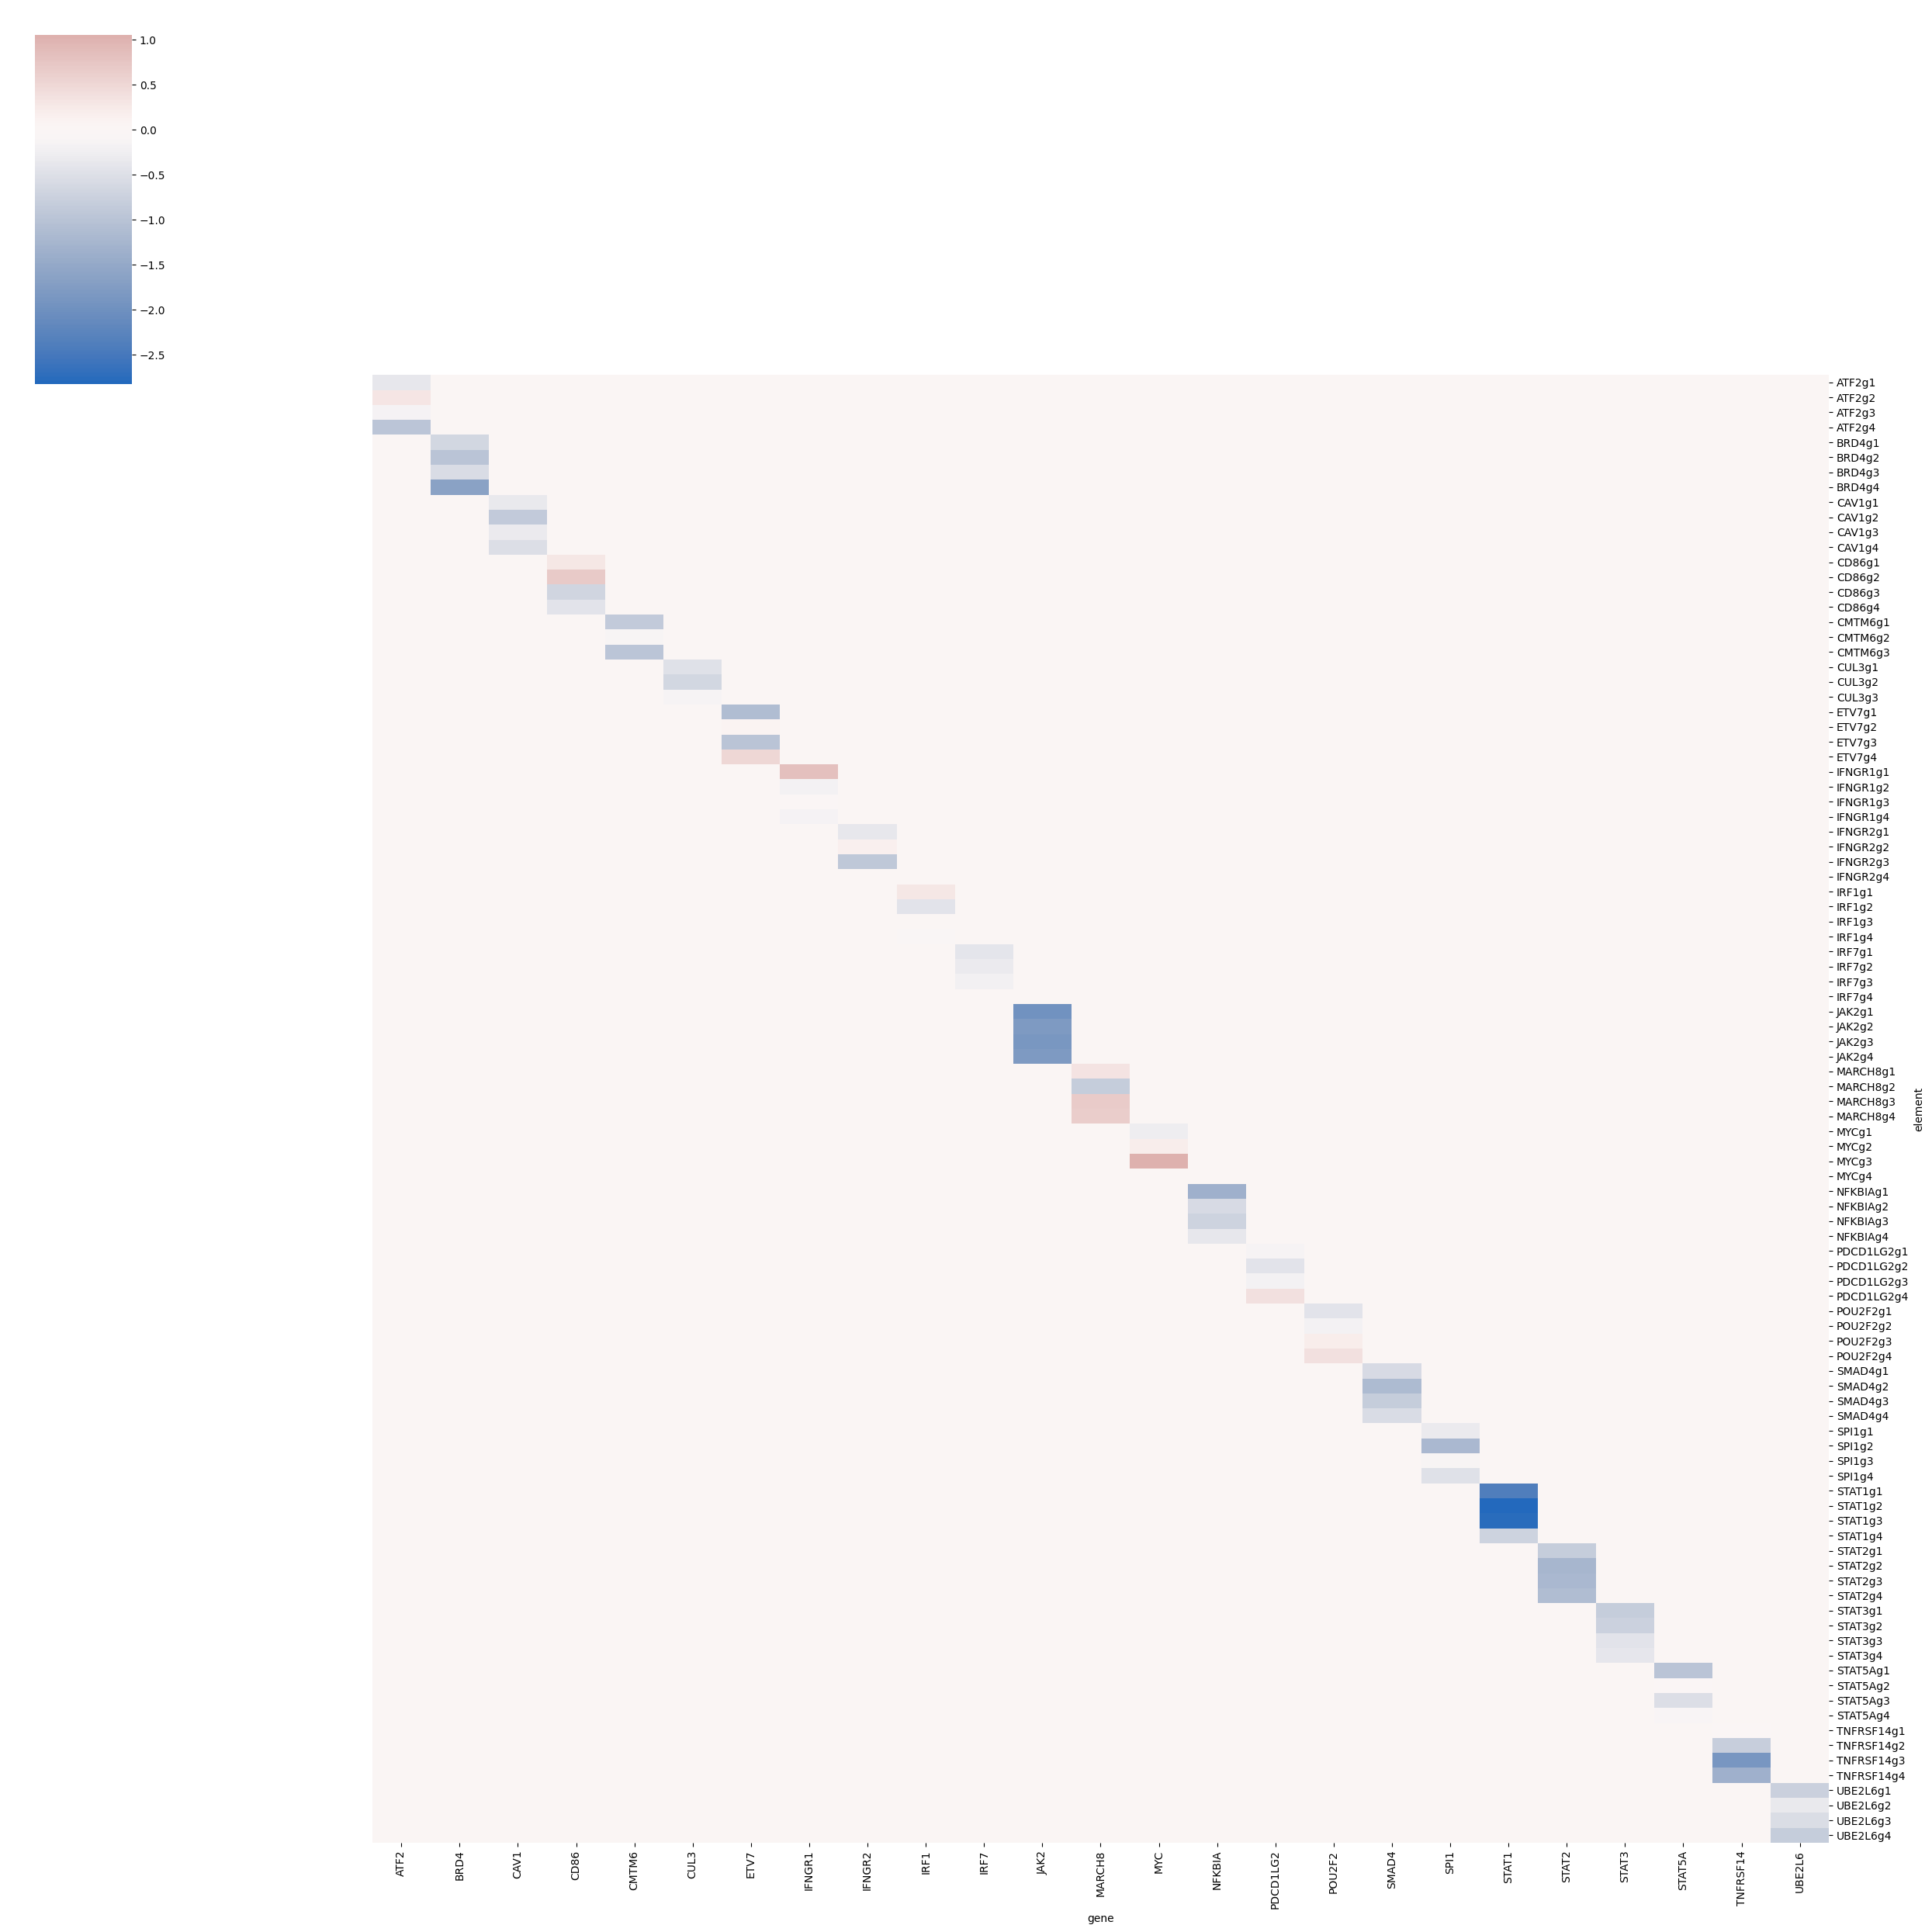

In [53]:
sns.clustermap(
    effects_df,
    center=0,
    # vmax=20,
    # vmin=-20,
    cmap="vlag",
    metric="cosine",
    figsize=(25, 25),
    col_cluster=False,
    row_cluster=False
)

## Posterior simulations

In [ ]:
model.module.guide.median().items()


dict_items([('guide_efficacy', tensor([[0.2561],
        [0.2413],
        [0.3497],
        [0.2326],
        [0.7016],
        [0.6685],
        [0.3748],
        [0.3426],
        [0.3274],
        [0.3613],
        [0.2618],
        [0.2834],
        [0.2164],
        [0.2536],
        [0.2182],
        [0.3327],
        [0.3139],
        [0.1999],
        [0.4787],
        [0.3427],
        [0.2531],
        [0.6813],
        [0.3865],
        [0.2916],
        [0.2414],
        [0.3907],
        [0.7676],
        [0.5197],
        [0.8529],
        [0.6087],
        [0.8159],
        [0.6370],
        [0.6029],
        [0.6734],
        [0.5058],
        [0.4439],
        [0.7910],
        [0.8783],
        [0.2796],
        [0.2336],
        [0.4835],
        [0.3483],
        [0.6891],
        [0.7638],
        [0.7550],
        [0.8564],
        [0.2656],
        [0.2415],
        [0.2738],
        [0.2726],
        [0.4613],
        [0.3783],
        [0.4160],
        [0.8404

In [54]:
# element_effects = 
from pyro.infer import Predictive

# predictive_svi = Predictive(model, guide=guide, num_samples=500)(X_, None)

# with pyro.condition(data={"element_effects": torch.zeros_like(guide.median()["element_effects"])}):

posterior_sample = dict(**model.module.guide.median())
for k, v in posterior_sample.items():
    posterior_sample[k]=v.unsqueeze(0)
    print(k, posterior_sample[k].shape)

guide_efficacy torch.Size([1, 107, 1])
pert_factors torch.Size([1, 10, 98, 1])
pert_loadings torch.Size([1, 10, 1, 50])
cell_factors torch.Size([1, 2, 20729, 1])
cell_loadings torch.Size([1, 2, 1, 50])
pert_cell_factors torch.Size([1, 2, 98, 1])
log_gene_mean torch.Size([1, 50])
log_gene_dispersion torch.Size([1, 50])
batch_effect torch.Size([1, 5, 50])
cont_covariate_effect torch.Size([1, 3, 50])
crispr_loading torch.Size([1, 50])
element_effects torch.Size([1, 98])


In [55]:
model.module.n_cells = 27

[]

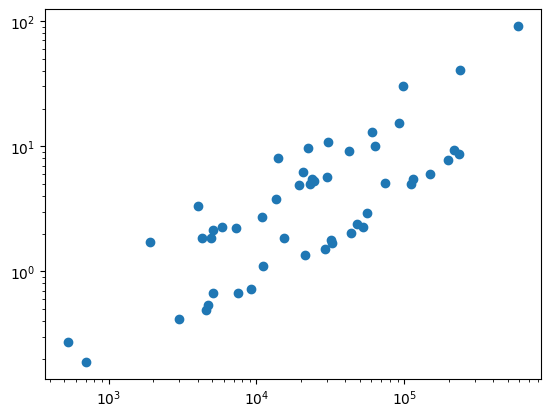

In [56]:
mean_variance = plt.scatter(mdata["rna"].X.sum(axis=0).A1, np.std(mdata["rna"].X.todense(),axis=0).A1)
plt.loglog()

In [57]:
from collections import defaultdict
dd = defaultdict(lambda : 1)
dd["hello"]
dd

defaultdict(<function __main__.<lambda>()>, {'hello': 1})

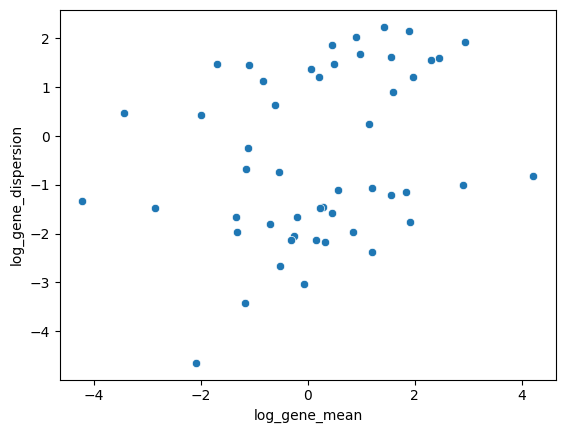

PearsonRResult(statistic=0.2875864861424358, pvalue=0.042855801819953535)

In [58]:
# # plt.scatter(posterior_sample["log_gene_mean"], posterior_sample["log_gene_dispersion"])
from scipy.stats import pearsonr

log_gene_mean = posterior_sample["log_gene_mean"].squeeze().numpy()
log_gene_dispersion = posterior_sample["log_gene_dispersion"].squeeze().numpy()
sns.scatterplot(x=log_gene_mean, y=log_gene_dispersion)
plt.ylabel("log_gene_dispersion")
plt.xlabel("log_gene_mean")

plt.show()

pearsonr(log_gene_mean, log_gene_dispersion)
# log_gene_mean
# plt.show()
# posterior_sample["log_gene_mean"].numpy()

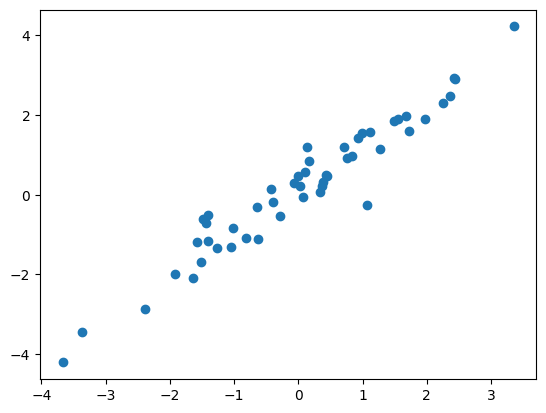

In [59]:
plt.scatter(np.log(mdata["rna"].X.mean(axis=0).A1), posterior_sample["log_gene_mean"])

In [60]:
if "multiplicative_noise" in posterior_sample:
    # posterior_sample["multiplicative_noise"]=np.zeros(mdata["rna"].n_vars)
    plt.scatter(posterior_sample["log_gene_mean"], np.log(posterior_sample["multiplicative_noise"]))
    plt.show()


In [61]:
## change the values of the 
# sites_to_zero_out = ["element_effects", "pert_loadings"]
# for site in sites_to_zero_out:
#     posterior_sample[site] = torch.zeros_like(posterior_sample[site])

## change the values of the guides by genes matrix
subset_idx = None
posterior_sample["log_gene_mean"] = posterior_sample["log_gene_mean"]
args, kwargs = model._get_data_subset(subset_idx)
args = [a.to(device) for a in args]
kwargs = {k: v.to(device) for k, v in kwargs.items()}
kwargs["X"] = None # sample counts instead of using observed
# kwargs["size_factor"] = torch.zeros_like(kwargs["size_factor"])  # no size factor



# serving_model = infer_discrete(model.module, first_available_dim=-4)
predictive_model = Predictive(model.module, posterior_samples=posterior_sample)
posterior_predictive = predictive_model(*args, **kwargs)["obs"].squeeze().numpy()
# posterior_sample = model.sample_posterior(num_samples=1, return_sites=["obs"])
posterior_predictive.shape

dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])


(20729, 50)

In [62]:
print(posterior_predictive.sum()/mdata["rna"].X.sum())

0.95763564


In [63]:
import ipywidgets as widgets
from ipywidgets import interact

def compare_plot(x1, x2, func: np.mean, labels=["observed", "simulated"], axis=0, log_scale=True, plot_type="scatter"):
    x1_transform = func(x1, axis=axis)
    x2_transform = func(x2, axis=axis)
    if isinstance(x1, np.matrix):
        x1_transform = x1_transform.A1
    if isinstance(x2, np.matrix):
        x2_transform = x2_transform.A1
    stat_type = "gene" if axis == 0 else "cell"
    if plot_type == "scatter":
        sns.scatterplot(x=x1_transform, y=x2_transform)
        plt.xlabel(labels[0])
        plt.ylabel(labels[1])
        if log_scale:
            plt.loglog()

    elif plot_type == "boxplot":
        sns.boxplot([x1_transform, x2_transform])
        if log_scale:
            plt.semilogy()
        plt.xticks(ticks=[0,1],labels=labels)
    plt.title(f"per-{stat_type} {func.__name__}")
    plt.show()

def zero_fraction(x, axis=0):
    return np.mean(x > 0, axis=axis)

def cv(x, axis=0):
    return np.std(x, axis=axis) / np.mean(x, axis=axis)

func_options = {
    "mean": np.mean,
    "std": np.std,
    "max": np.max,
    "zero_fraction": zero_fraction,
    "cv": cv
}

axis_widget = widgets.Dropdown(
    options=[0, 1],
    value=0,
    description="Axis:"
)

func_widget = widgets.Dropdown(
    options=list(func_options.keys()),
    value="mean",
    description="Function:"
)

plot_type_widget = widgets.Dropdown(
    options=["scatter", "boxplot"],
    value="scatter",
    description="Plot Type:"
)

log_scale_widget = widgets.Checkbox(
    value=True,
    description="Log Scale"
)

@interact(axis=axis_widget, func=func_widget, plot_type=plot_type_widget, log_scale=log_scale_widget)
def update_plot(axis, func, plot_type, log_scale):
    compare_plot(mdata["rna"].X.todense(), posterior_predictive, func_options[func], axis=axis, plot_type=plot_type, log_scale=log_scale)


interactive(children=(Dropdown(description='Axis:', options=(0, 1), value=0), Dropdown(description='Function:'…

In [64]:
import ipywidgets as widgets
from ipywidgets import interact

def compare_plot_2d(
    x1, x2, func1, func2, labels=["observed", "simulated"], axis=0, log_scale=True, plot_type="scatter"
):
    x1_f1 = func1(x1, axis=axis)
    x2_f1 = func1(x2, axis=axis)
    x1_f2 = func2(x1, axis=axis)
    x2_f2 = func2(x2, axis=axis)
    if isinstance(x1, np.matrix):
        x1_f1 = x1_f1.A1
        x1_f2 = x1_f2.A1
    if isinstance(x2, np.matrix):
        x2_f1 = x2_f1.A1
        x2_f2 = x2_f2.A1
    stat_type = "gene" if axis == 0 else "cell"
    if plot_type == "scatter":
        plt.scatter(x1_f1, x1_f2, label=labels[0],)
        plt.scatter(x2_f1, x2_f2, label=labels[1],)
        plt.xlabel(func1.__name__)
        plt.ylabel(func2.__name__)
        if log_scale:
            plt.loglog()

    plt.title(f"per-{stat_type} {func1.__name__} vs.  {func2.__name__}")
    plt.legend()
    plt.show()

func_options = {
    "mean": np.mean,
    "std": np.std,
    "max": np.max,
    "zero_fraction": zero_fraction,
}

axis_widget = widgets.Dropdown(
    options=[0, 1],
    value=0,
    description="Axis:"
)

func1_widget = widgets.Dropdown(
    options=list(func_options.keys()),
    value="mean",
    description="Function 1:"
)

func2_widget = widgets.Dropdown(
    options=list(func_options.keys()),
    value="std",
    description="Function 2:"
)

log_scale_widget = widgets.Checkbox(
    value=True,
    description="Log Scale"
)

# plot_type_widget = widgets.Dropdown(
#     options=["scatter", "boxplot"],
#     value="scatter",
#     description="Plot Type:"
# )

@interact(axis=axis_widget, func1=func1_widget, func2=func2_widget, log_scale=log_scale_widget)
def update_plot(axis, func1, func2, log_scale):
    compare_plot_2d(mdata["rna"].X.todense(), posterior_predictive, func_options[func1], func_options[func2], axis=axis, log_scale=log_scale)

interactive(children=(Dropdown(description='Axis:', options=(0, 1), value=0), Dropdown(description='Function 1…

Text(0.5, 0.98, 'Gene-gene correlation')

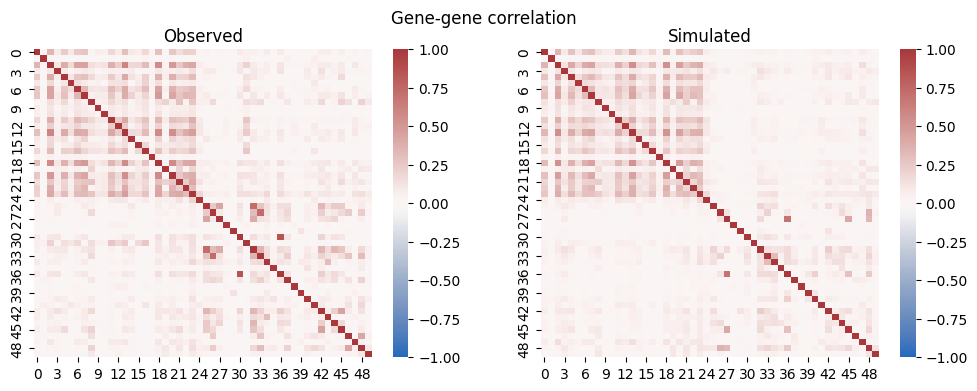

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))
corr_obs = np.corrcoef(mdata["rna"].X.todense(), rowvar=False)
corr_sim = np.corrcoef(posterior_predictive, rowvar=False)
ax1.set_title("Observed")
sns.heatmap(corr_obs, center=0, cmap="vlag", vmax=1, vmin=-1, ax=ax1)
ax2.set_title("Simulated")
sns.heatmap(corr_sim, center=0, cmap="vlag", vmax=1, vmin=-1, ax=ax2)
fig.suptitle("Gene-gene correlation")

In [66]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
# plot_genes

In [67]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['STAT1',
 'ETV7',
 'TNFRSF14',
 'MARCH8',
 'CD86',
 'MYC',
 'ATF2',
 'IFNGR2',
 'BRD4',
 'IFNGR1',
 'SPI1',
 'CMTM6',
 'STAT5A',
 'NFKBIA',
 'POU2F2',
 'PDCD1LG2',
 'IRF1',
 'SMAD4',
 'CUL3',
 'CAV1',
 'UBE2L6',
 'STAT3',
 'IRF7',
 'STAT2',
 'JAK2']

In [68]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

In [69]:
# if not smoke_test:
#     pyro.get_param_store().save("params.save")
# if not smoke_test:
model.save("papalexi_save", save_anndata=True, overwrite=True)

In [70]:
perturbo.PERTURBO.load("papalexi_save")

INFO     File papalexi_save/model.pt already downloaded                                                            


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Se

Epoch 1/-1: : 0it [00:00, ?it/s]dict_keys(['X', 'size_factor', 'perturbations', 'batch', 'ind_x', 'extra_continuous_covs'])
Epoch 1/-1: : 1it [00:00, 13.30it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/-1: : 1it [00:00, 12.91it/s, v_num=1]


MyPyroModel Model with params:
n_batch: 5
n_cells: 20729
n_extra_continuous_covs: 2
n_perturbations: 107
n_targeted_elements: 98
n_tested_elements: 98
n_vars: 50

Training status: Trained
Model's adata is minified?: False

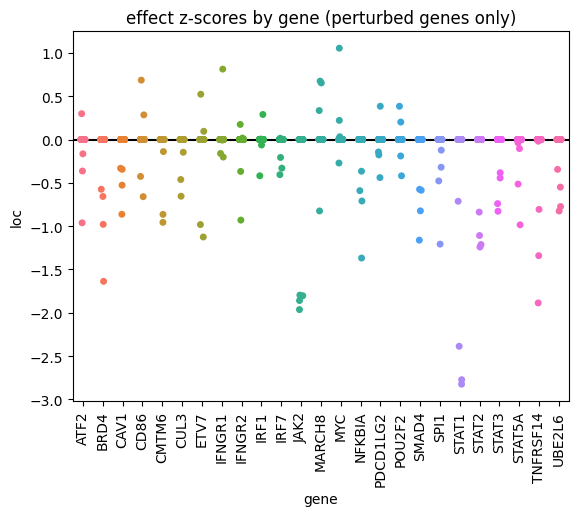

In [71]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

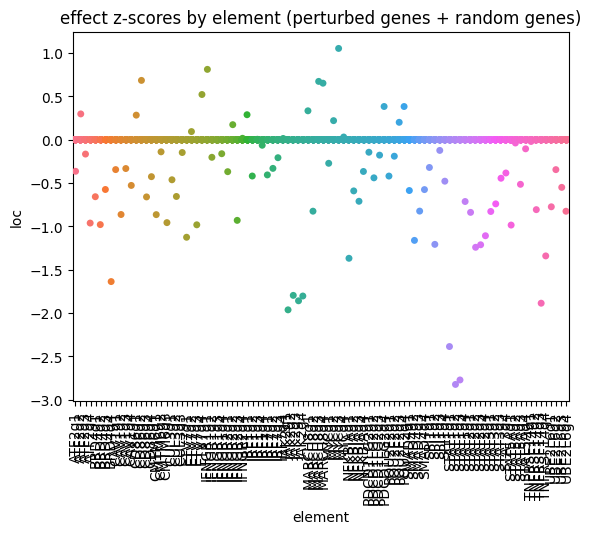

In [72]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

## Factor Analysis

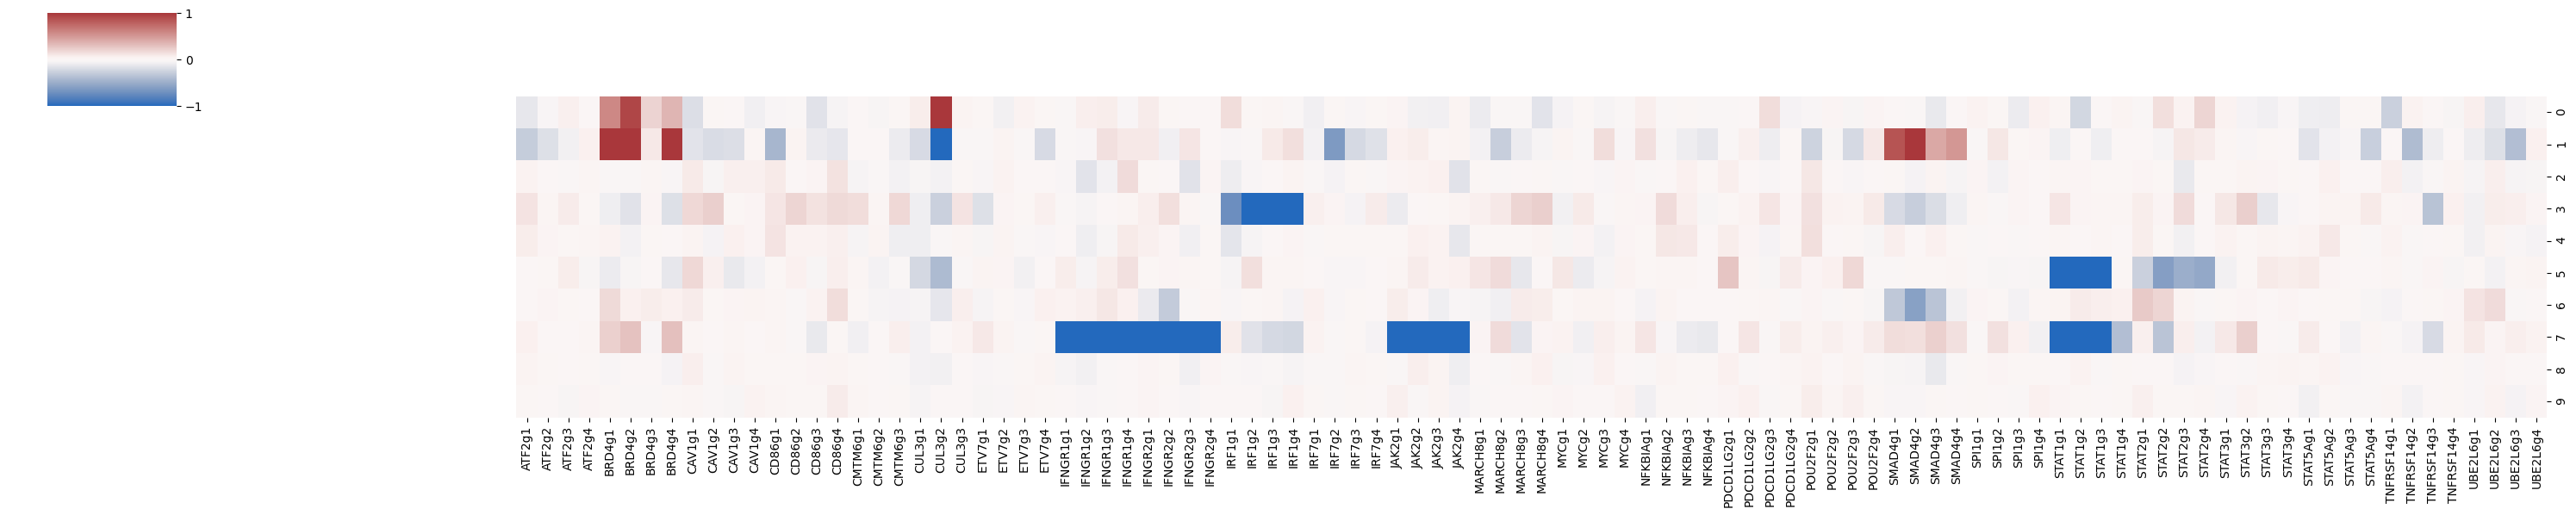

In [73]:
# if len(elements)!=model.module.n_perturbations:
    # elements = mdata["grna"].var_names
if "pert_factors" in model.module.guide.median():
    elements=targeting_guides
    pert_factors = pd.DataFrame(
        model.module.guide.median()["pert_factors"].squeeze(),
        columns=elements,
    )
    sns.clustermap(pert_factors, cmap="vlag", figsize=(30, 6), row_cluster=False, col_cluster=False, center=0, vmin=-1, vmax=1)
    pert_factors



In [74]:
# pert_factors_avg


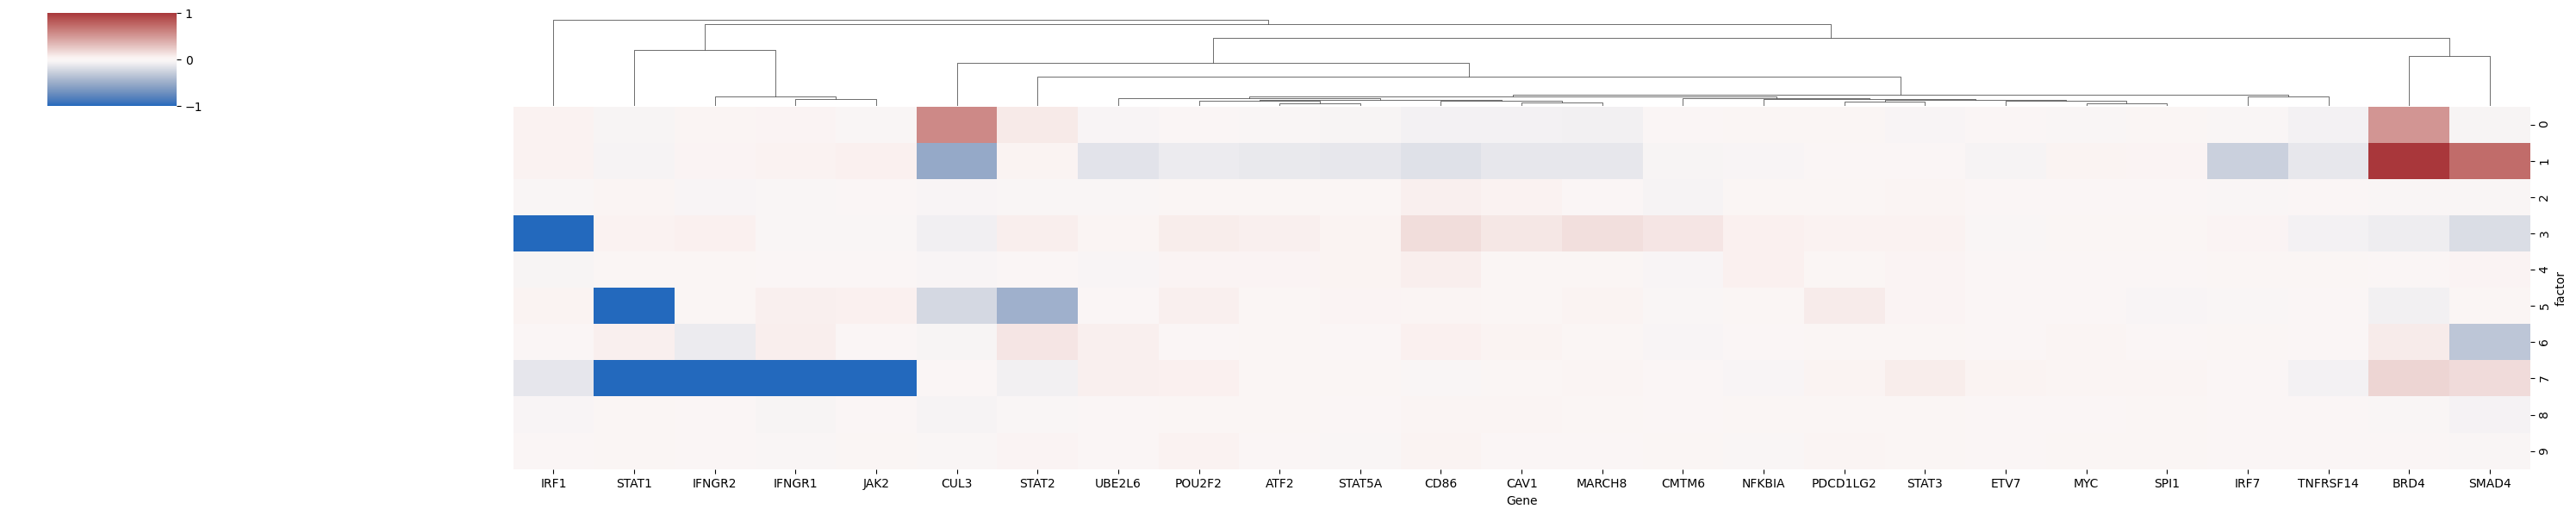

In [75]:
# find the factors that are most loaded up for each perturbed gene
if "pert_factors" in model.module.guide.median():
    pert_factors_anno = (
        pert_factors.melt(ignore_index=False, var_name="guide_id")
        .reset_index(names="factor")
        .merge(mdata["grna"].var.reset_index(names="guide_id"))
    )
    pert_factors_avg = pert_factors_anno.groupby(["Gene", "factor"], observed=True)["value"].mean().reset_index()

    # sns.histplot(pert_factors_avg["value"], binwidth=0.1)

    sns.clustermap(
        pert_factors_avg.pivot(index="factor", columns="Gene", values="value"),
        cmap="vlag",
        figsize=(30, 6),
        row_cluster=False,
        # col_cluster=False,
        center=0,
        vmin=-1,
        vmax=1,
    )
    pert_factors_avg.query("abs(value)>0.2").sort_values(["factor"])


In [76]:
if "pert_factors" in model.module.guide.median():

    pert_loadings = pd.DataFrame(
        model.module.guide.median()["pert_loadings"].squeeze(),
        columns=mdata["rna"].var_names,
    )

    pert_loadings


In [77]:
if "pert_factors" in model.module.guide.median():

    n_genes_per_factor = 5
    top_genes_per_factor_df = (
        pert_loadings.transform(abs)
        .melt(ignore_index=False)
        .reset_index(names="factor")
        .sort_values("value")
        .groupby("factor")
        .tail(n_genes_per_factor)
        .sort_values("factor")
    )
    top_genes_per_factor_df

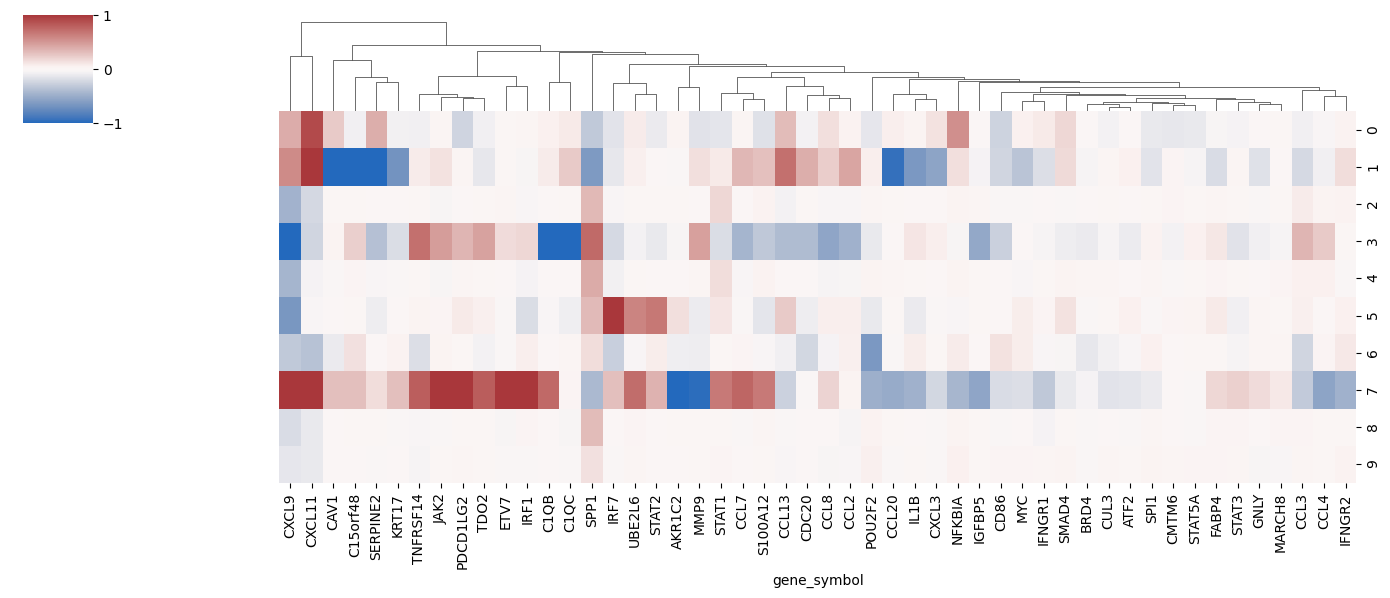

In [78]:
top_genes = (np.abs(pert_loadings)).max().nlargest(100).index
# top_genes = pert_loadings.melt().groupby("")
# top_genes = top_genes_df["gene_symbol"]

pert_loadings_subset = pert_loadings.loc[:, top_genes]
sns.clustermap(
    pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0, vmin=-1, vmax=1
)


In [79]:
# top_genes = pert_loadings.melt().groupby("")
# top_genes = top_genes_df["gene_symbol"]

# pert_loadings_subset = pert_loadings.loc[:, top_genes]
# sns.clustermap(pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0, vmin=-1, vmax=1)


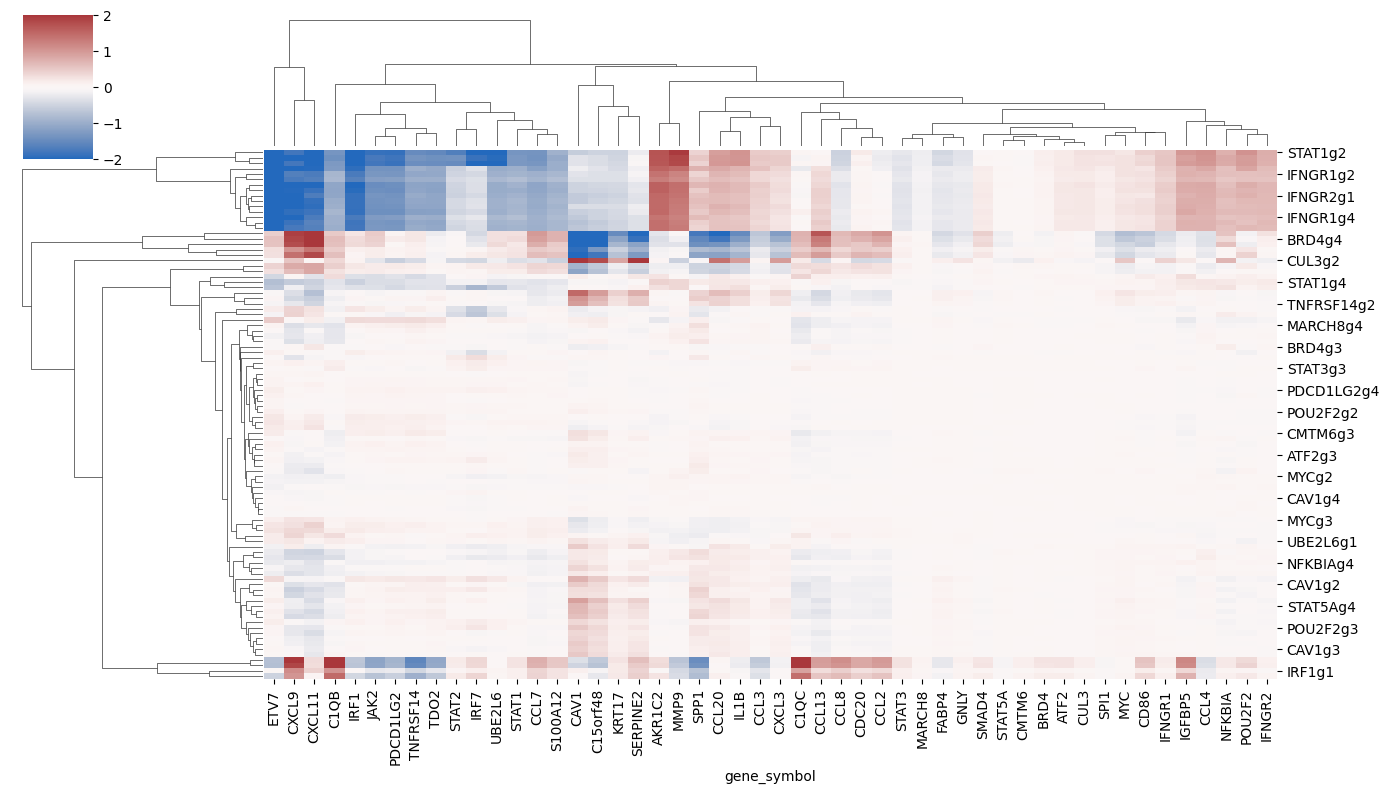

In [80]:
reconstructed_effects = pd.DataFrame(
    pert_factors.values.T @ pert_loadings.values,
    index=elements,
    columns=mdata["rna"].var_names,
)
sns.clustermap(reconstructed_effects, center=0, cmap="vlag", figsize=(14, 8),vmin=-2,vmax=2)

In [81]:
# reconstructed_effects.loc["CUL3"].sort_values().tail(20)

In [82]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df


## Experiment: using pyro primitives for the simulation engine
sampling from a modified model with different elements but same per-gene/global params?

In [83]:
# create a new model to simulate fake counts from?
n_subsample = 1000
mdata_2_idx = np.random.choice(mdata.n_obs, size=1000)
assert mdata_2_idx.shape == (n_subsample,)

# mdata.uns=None
mdata_2 = mdata[mdata_2_idx, :].copy()

perturbo.PERTURBO.setup_mudata(
    mdata_2,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_identity",
    # gene_by_element_key="guide_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model_2 = perturbo.PERTURBO(
    mdata_2,
    likelihood="lnnb",
    efficiency_mode="scaled",
    merge_guides_mode="shared",
    n_factors=None,
    n_pert_factors=None,
)

model_2.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/mudata/_core/mudata.py:322: UserWarning: Duplicated obs_names should not be present in different modalities due to the ambiguity that leads to.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/mudata/_core/mudata.py:322: UserWarning: Duplicated obs_names should not be present in different modalities due to the ambiguity that leads to.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/muda

KeyError: 'AGCGGTCCACAACGTT'